모델의 R-squared (결정 계수): 0.8994
새로운 데이터 예측 판매량 (TV:200, Radio:50, Newspaper:30): 21.47


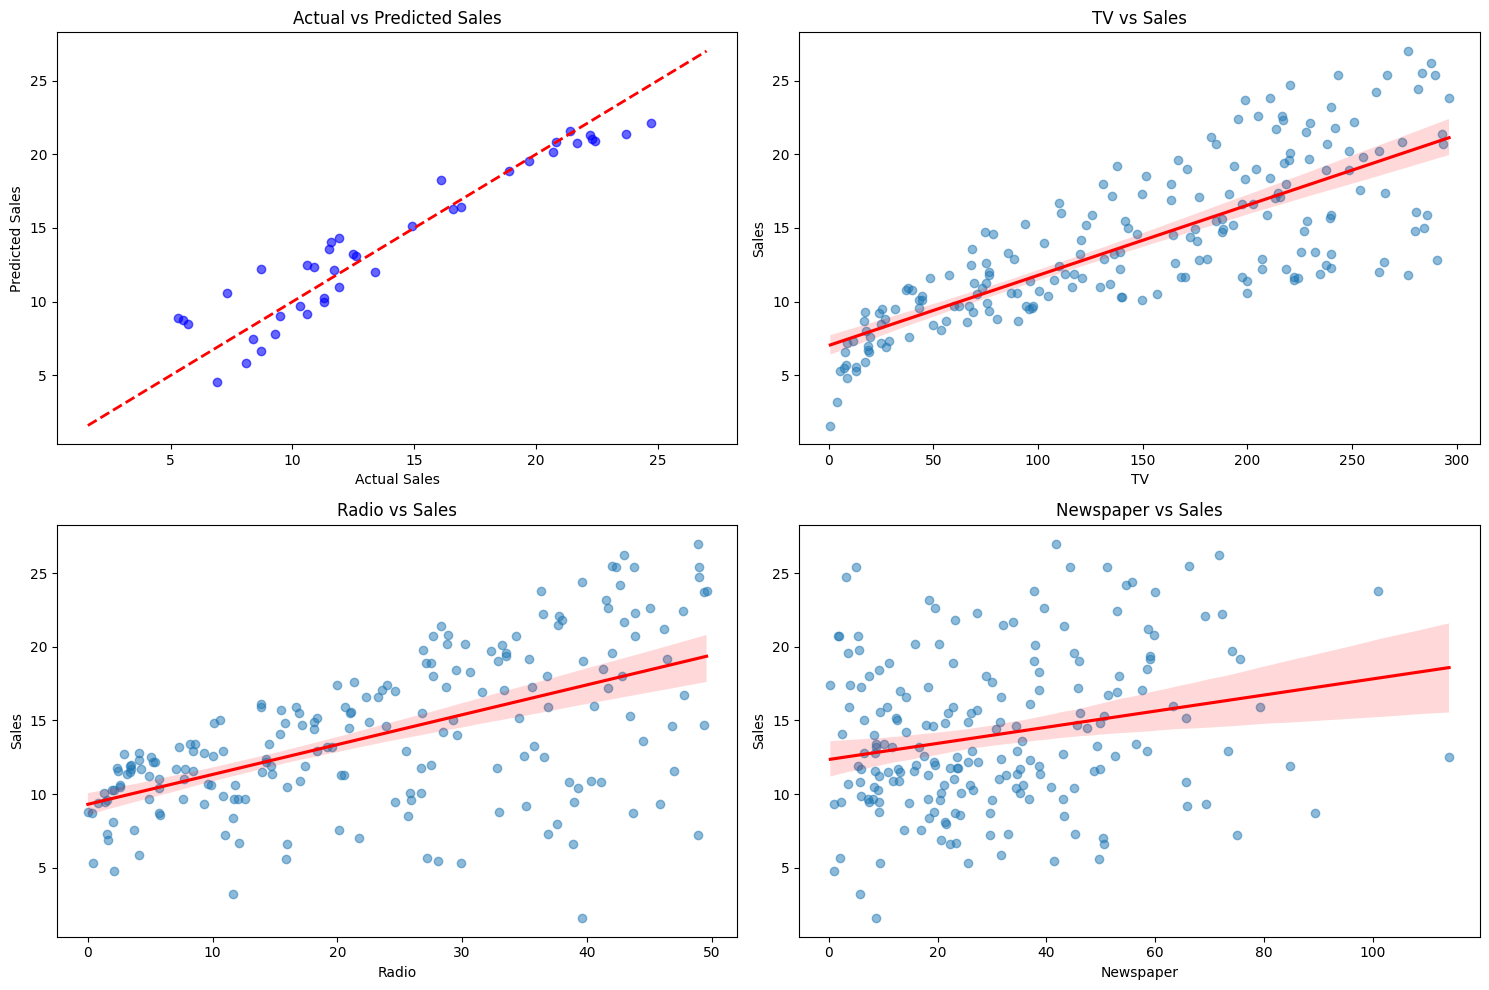

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 1. 데이터 로드
df = pd.read_csv('dataset/Advertising.csv')

# 2. 데이터 전처리
# 불필요한 'Unnamed: 0' 컬럼 제거
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# 독립 변수(X)와 종속 변수(y) 설정
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

# 3. 데이터 분할 (8:2 비율)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. 모델 학습
model = LinearRegression()
model.fit(X_train, y_train)

# 5. 예측 (테스트 데이터)
y_pred = model.predict(X_test)

# 6. 모델 평가 (R-squared)
r2 = r2_score(y_test, y_pred)

# 7. 새로운 데이터 예측 (TV=200, Radio=50, Newspaper=30)
data = pd.DataFrame([[200, 50, 30]], columns=['TV', 'Radio', 'Newspaper'])
prediction = model.predict(data)

# 8. 결과 출력
print(f"모델의 R-squared (결정 계수): {r2:.4f}")
print(f"새로운 데이터 예측 판매량 (TV:200, Radio:50, Newspaper:30): {prediction[0]:.2f}")

# 9. 시각화
plt.figure(figsize=(15, 10))

# (1) 실제 판매량 vs 예측 판매량 산점도
plt.subplot(2, 2, 1)
plt.scatter(y_test, y_pred, color='blue', alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.title('Actual vs Predicted Sales')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')

# (2) 각 독립변수와 판매량 관계 (회귀선 포함)
features = ['TV', 'Radio', 'Newspaper']
colors = ['green', 'orange', 'purple']

for i, feature in enumerate(features):
    plt.subplot(2, 2, i+2)
    sns.regplot(x=feature, y='Sales', data=df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
    plt.title(f'{feature} vs Sales')

plt.tight_layout()
plt.show()